# Implementação do modelo K-vizinhos mais próximos

## Importações iniciais

In [521]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import RobustScaler

## Funções

## Classes

In [522]:
class KNN:
    def __init__(self,k:int=3) -> None:
        self.k = k
    def fit(self, X, y) -> None:
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y, dtype=np.float64)

        # Previsão sobre os dados de treinamento
        y_pred_train = self.predict(self.X_train)

        # Cálculo do MSE no treinamento
        self.mse = self.rmse(y,y_pred_train)

    def predict(self,X)->float:
        X = np.asarray(X,dtype=np.float64)

        #Distância euclidiana vetorizada
        distancias = np.linalg.norm(X[:,np.newaxis,:]-self.X_train,axis=2)
        #indices dos k-vizinhos
        k_indices = np.argsort(distancias,axis=1)[:,:self.k]
        #Valores dos k-vizinhos
        k_vizinhos_y = self.y_train[k_indices]

        return np.mean(k_vizinhos_y,axis=1)
    
    def rmse(self,y_true,y_predi):
        y_true = np.asarray(y_true,dtype=np.float64)
        y_predi = np.asarray(y_predi,dtype=np.float64)

        #Raizz do mse
        return np.sqrt(np.mean((y_true-y_predi)**2))

## Modelagem bruta

### Dataset

In [523]:
X, y = load_diabetes(return_X_y=True,as_frame=True,scaled=False)

In [524]:
display(X.head(),y.head())
print(f"Média da variável alvo:{np.mean(y)}")

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

Média da variável alvo:152.13348416289594


Como o professor solicitou que considerasse apenas uma feature inicialmente, então irei escolher a mais linearmente correlacionada.

In [525]:
for col in X.columns:
    display(np.corrcoef(X[col],y)[0][1])

np.float64(0.18788875071891978)

np.float64(0.043061998451605334)

np.float64(0.5864501344746885)

np.float64(0.4414817585625713)

np.float64(0.2120224810145507)

np.float64(0.17405358696874262)

np.float64(-0.3947892506709184)

np.float64(0.43045288474477267)

np.float64(0.5658825924427439)

np.float64(0.3824834842485811)

Não gostei do resultado mas faz parte. A feature escolhida é a $bmi$, "Body Mass Index".

In [526]:
X_ = X["bmi"]

In [527]:
X_train, X_test, y_train, y_test = train_test_split(X_,y,test_size=0.2,random_state=0,shuffle=True)

In [528]:
rb = RobustScaler()
X_train = rb.fit_transform(pd.DataFrame(X_train))
X_test = rb.transform(pd.DataFrame(X_test))

### Caso inicial $k=3$

In [529]:
knn = KNN(k=3)
knn.fit(X_train,y_train)
y_predi = knn.predict(X_test)
knn.rmse(y_test,y_predi)

np.float64(76.16482881595871)

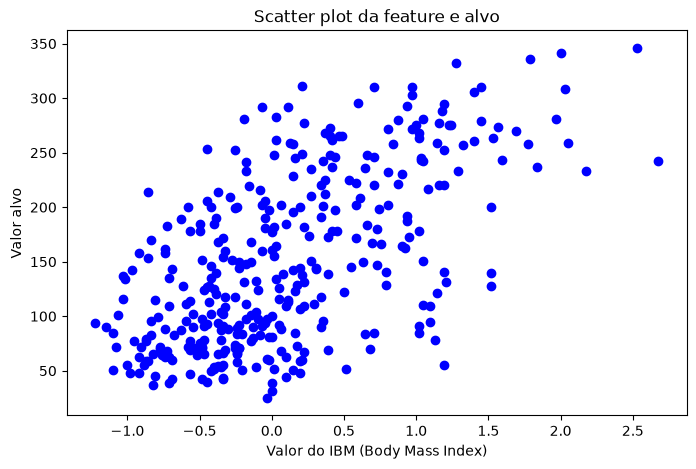

In [530]:
plt.figure(figsize=(8,5))
plt.title("Scatter plot da feature e alvo")
plt.scatter(X_train,y_train,color="blue")
plt.xlabel("Valor do IBM (Body Mass Index)")
plt.ylabel("Valor alvo")
plt.show()

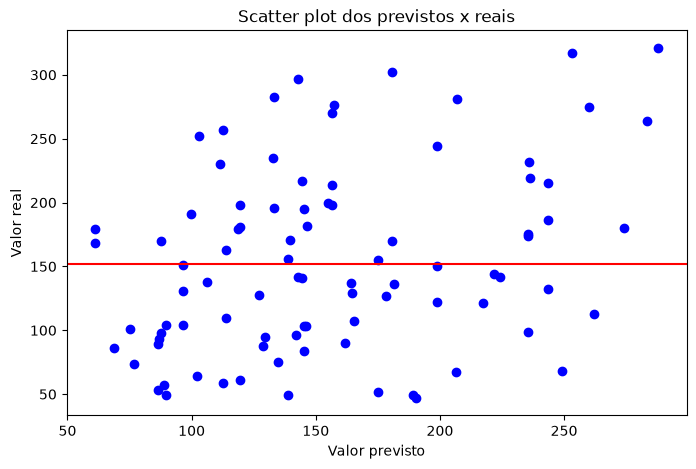

In [531]:
plt.figure(figsize=(8,5))
plt.title("Scatter plot dos previstos x reais")
plt.scatter(y_predi,y_test,color="blue")
plt.axhline(np.mean(y_train),color="red")
plt.xlabel("Valor previsto")
plt.ylabel("Valor real")
plt.show()

### Demais valores de $k$

Os valores pra k solicitados foram 1,3,5,10,20 e 50.

In [532]:
ks = [1,3,5,10,20,30,40,50]
rmses = []
rmses_train = []

In [533]:
for k in ks:
    knn = KNN(k)
    knn.fit(X_train,y_train)
    y_predi = knn.predict(X_test)
    rmses_train.append((k,knn.mse))
    rmses.append((k,knn.rmse(y_test,y_predi)))

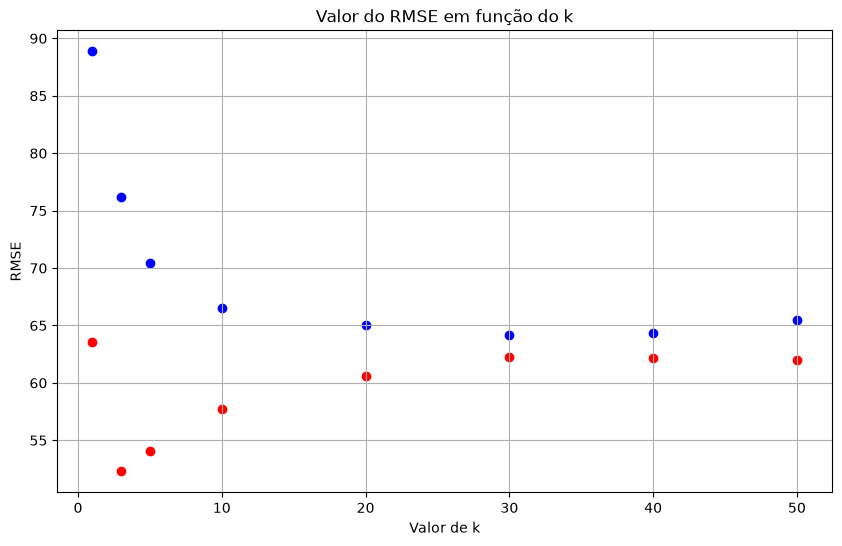

In [534]:
plt.figure(figsize=(10,6))
plt.title("Valor do RMSE em função do k")
plt.scatter(*zip(*rmses),color="blue",label="Teste")
plt.scatter(*zip(*rmses_train),color="red",label="Treino")
plt.xlabel("Valor de k")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

### Demais valores de $k$ e dataset completo

Os valores pra k solicitados foram 1,3,5,10,20 e 50.

In [535]:
ks = [1,3,5,10,20,30,40,50]
rmses = []
rmses_train = []

In [536]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0,shuffle=True)
rb = RobustScaler()
X_train = rb.fit_transform(X_train)
X_test = rb.transform(X_test)

In [537]:
for k in ks:
    knn = KNN(k)
    knn.fit(X_train,y_train)
    y_predi = knn.predict(X_test)
    rmses_train.append((k,knn.mse))
    rmses.append((k,knn.rmse(y_test,y_predi)))

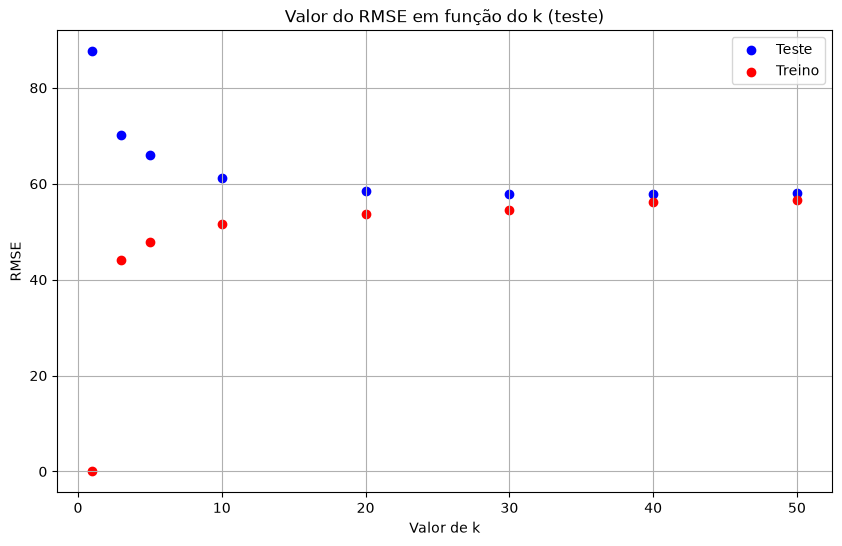

In [538]:
plt.figure(figsize=(10,6))
plt.title("Valor do RMSE em função do k (teste)")
plt.scatter(*zip(*rmses),color="blue",label="Teste")
plt.scatter(*zip(*rmses_train),color="red",label="Treino")
plt.xlabel("Valor de k")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Como foi observado, considerando apenas uma feature, o melhor valor de $k$ observado foi $k=30$, com rmse de aproxidamente 64.1, enquanto considerando todas as features, o melhor valor de $k$ observado foi também $k=30$ mas com rmse de 57.8

## Modelagem com scikit-learn

### Caso com apenas uma feature

In [539]:
rmses = []

In [540]:
X_train, X_test, y_train, y_test = train_test_split(X_,y,test_size=0.2,random_state=0,shuffle=True)
rb = RobustScaler()
X_train = rb.fit_transform(pd.DataFrame(X_train))
X_test = rb.transform(pd.DataFrame(X_test))

In [541]:
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_predi = knn.predict(X_test)
    rmse = root_mean_squared_error(y_test,y_predi)
    rmses.append((k,rmse))

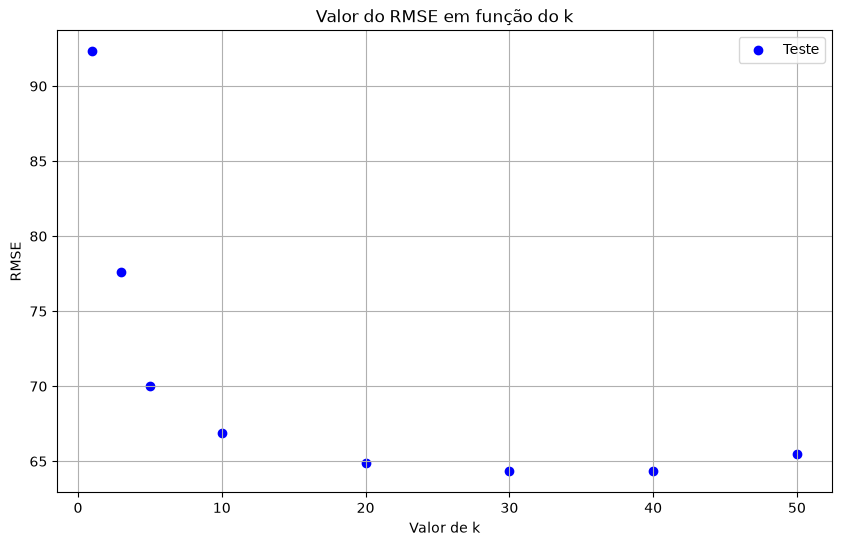

In [542]:
plt.figure(figsize=(10,6))
plt.title("Valor do RMSE em função do k")
plt.scatter(*zip(*rmses),color="blue",label="Teste")
plt.xlabel("Valor de k")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Agora com apenas uma feature no scikit-learn, o melhor desempenho foi observado para $k=40$ com rmse de 64.31

### Caso com todas as features

In [543]:
rmses = []

In [544]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0,shuffle=True)
rb = RobustScaler()
X_train = rb.fit_transform(pd.DataFrame(X_train))
X_test = rb.transform(pd.DataFrame(X_test))

In [545]:
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_predi = knn.predict(X_test)
    rmse = root_mean_squared_error(y_test,y_predi)
    rmses.append((k,rmse))

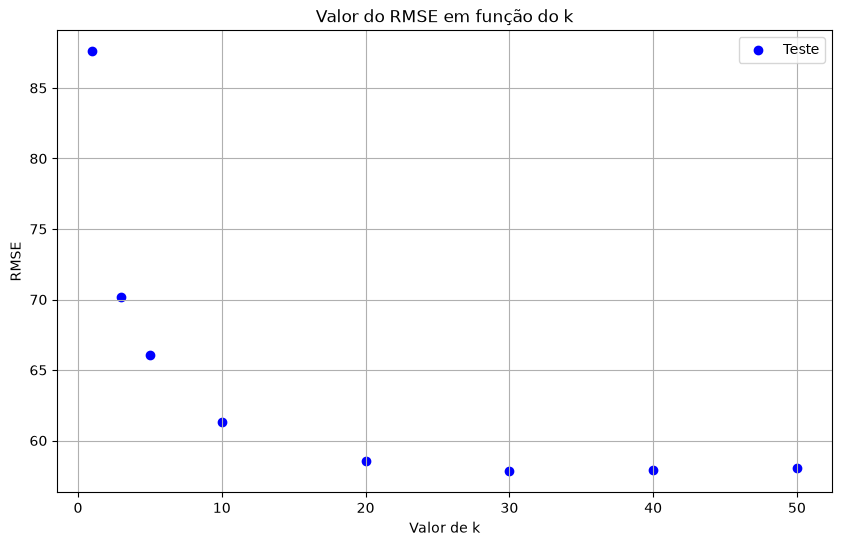

In [546]:
plt.figure(figsize=(10,6))
plt.title("Valor do RMSE em função do k")
plt.scatter(*zip(*rmses),color="blue",label="Teste")
plt.xlabel("Valor de k")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

Agora com a implementação do scikit-learn, o melhor valor de $k$ foi $k=30$ com rmse de 57.8, igual ao da implementação bruta.